## 1.Loading Needed Libraries

In [1]:
import glob
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 8)

## 2.Loading Files

In [2]:
files = glob.glob('../data/raw/item_properties_part?.csv')

In [3]:
events = pd.read_csv('../data/raw/events.csv')
category_tree = pd.read_csv('../data/raw/category_tree.csv')
item_props = pd.concat([pd.read_csv(f)  for f in files], ignore_index=True)

## 3.Events

In [4]:
events.head(7)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN


In [5]:
print('Frequency of events')
print('_'*50)
print(events.value_counts('event').to_string())

Frequency of events
__________________________________________________
event
view           2664312
addtocart        69332
transaction      22457


In [6]:
shape_events = events.shape

print(f'Duplicates in events: {events.duplicated().sum()}')
print('_'*50)
print(f'Missing values in events:\n{events.isna().sum().to_string()}')
print('_'*50)
print(f'# of rows: {shape_events[0]}')
print(f'# of columns: {shape_events[1]}')
print('_'*50)
print(events.dtypes.to_string())

Duplicates in events: 460
__________________________________________________
Missing values in events:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
__________________________________________________
# of rows: 2756101
# of columns: 5
__________________________________________________
timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64


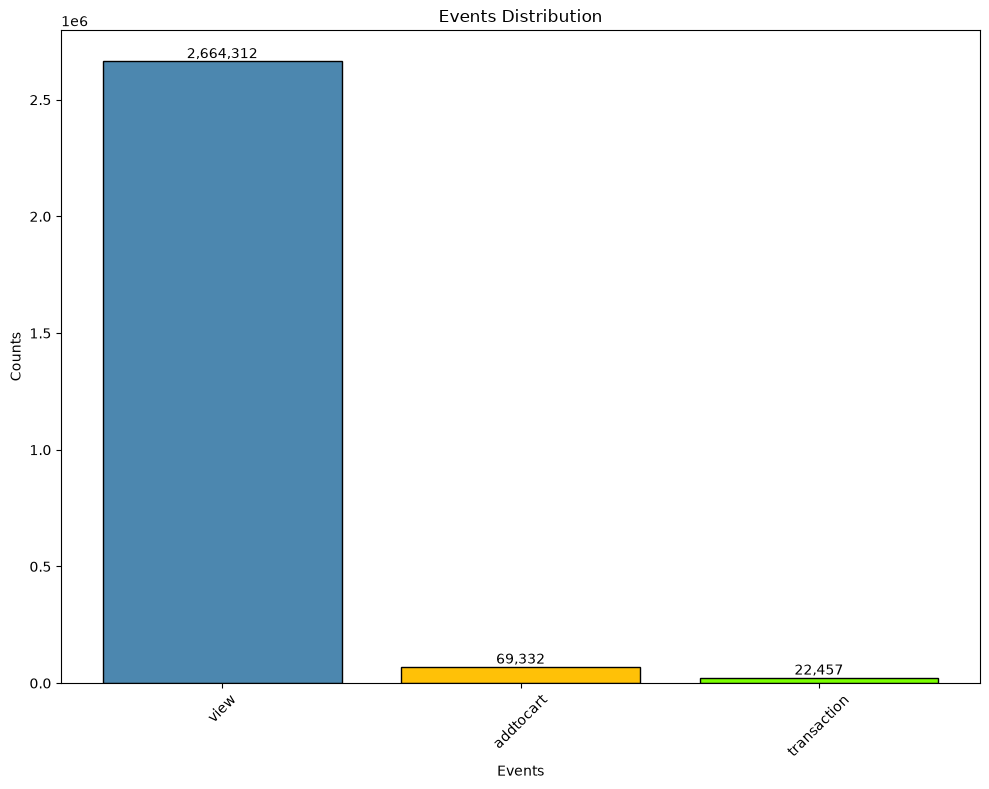

In [7]:
event_counts = events['event'].value_counts()

plt.bar(event_counts.index, event_counts.values, color=["#4C87AF", '#FFC107', "#7BFF00"], edgecolor='black', width=0.8)
plt.title('Events Distribution')
plt.xlabel('Events')
plt.ylabel('Counts')
plt.xticks(rotation=45)
for i, v in enumerate(event_counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../results/figures/event_frequency.png', dpi=200, bbox_inches='tight')
plt.show()

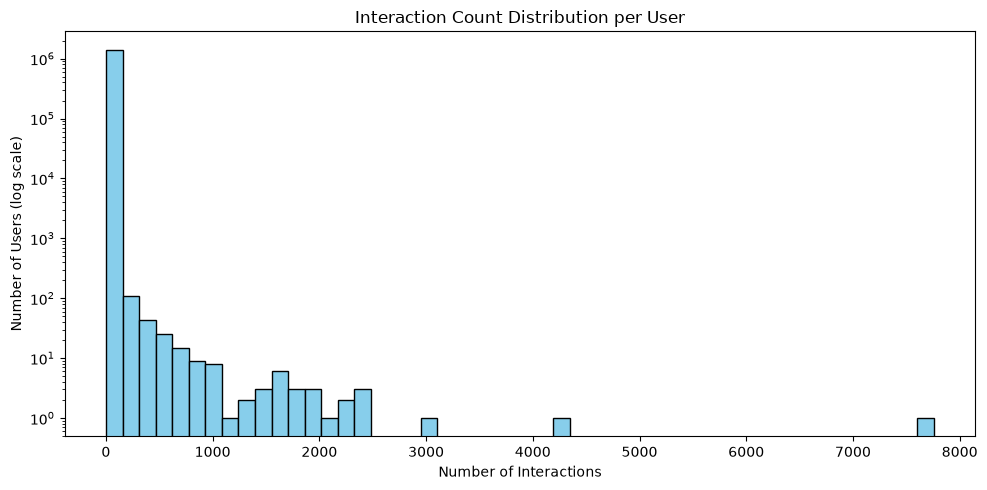

In [8]:
user_counts = events['visitorid'].value_counts()

plt.figure(figsize=(10, 5))
plt.hist(user_counts.values, bins=50, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.title('Interaction Count Distribution per User')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users (log scale)')
plt.tight_layout()
plt.savefig('../results/figures/user_interaction_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
print('Distribution of Interactions per User:')
print(user_counts.quantile([0.5, 0.9, 0.99]).to_string())

Distribution of Interactions per User:
0.50     1.0
0.90     3.0
0.99    13.0


## 4.Category Tree

In [10]:
category_tree.head(7)

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
5,231,NaN
6,542,378.0


In [11]:
shape_category_tree = category_tree.shape

print(f'Duplicated values in Category Tree: {category_tree.duplicated().sum()}')
print('_'*50)
print(f'Missing values in Category Tree:\n{category_tree.isna().sum().to_string()}')
print('\nCategories with missing parentid are root level categories (no parent above them)')
print('_'*50)
print(f'# of rows: {shape_category_tree[0]}')
print(f'# of columns: {shape_category_tree[1]}')
print('_'*50)
print(category_tree.dtypes.to_string())

Duplicated values in Category Tree: 0
__________________________________________________
Missing values in Category Tree:
categoryid     0
parentid      25

Categories with missing parentid are root level categories (no parent above them)
__________________________________________________
# of rows: 1669
# of columns: 2
__________________________________________________
categoryid      int64
parentid      float64


## 5. Item Properties (Part 1 and 2)

In [12]:
item_props.head(7)

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513
5,1436065200000,285026,available,0
6,1434250800000,89534,213,1121373


In [13]:
shape_item_props = item_props.shape

print(f'Duplicated values in Item Properties: {item_props.duplicated().sum()}')
print('_'*50)
print(f'Missing values in Item Properties:\n{item_props.isna().sum().to_string()}')
print('_'*50)
print(f'# of rows: {shape_item_props[0]}')
print(f'# of columns: {shape_item_props[1]}')
print('_'*50)
print(item_props.dtypes.to_string())
print('_'*50)
print(f'Number of unique item ID: {item_props['itemid'].nunique()}')
print(f'Number of unique properties: {item_props['property'].nunique()}')

Duplicated values in Item Properties: 0
__________________________________________________
Missing values in Item Properties:
timestamp    0
itemid       0
property     0
value        0
__________________________________________________
# of rows: 20275902
# of columns: 4
__________________________________________________
timestamp    int64
itemid       int64
property       str
value          str
__________________________________________________
Number of unique item ID: 417053
Number of unique properties: 1104


In [14]:
category_rows = item_props[item_props['property'] == 'categoryid']
available_rows = item_props[item_props['property'] == 'available']

print(category_rows['itemid'].nunique(), 'items have a categoryid out of', item_props['itemid'].nunique(), 'total items')
print('_'*50 +'\n')
print(available_rows['itemid'].nunique(), 'items have a available out of', item_props['itemid'].nunique(), 'total items')

417053 items have a categoryid out of 417053 total items
__________________________________________________

417053 items have a available out of 417053 total items
